## Dynamic Price Prediction in the Short-Term Rental Market
This project is implemented for educational purposes. It is submitted in fulfillment of Machine Learning (491114) course requirements.
<br>The Goal: help property owners to predict the optimal price of short-term rental properties based on its physical characteristics, geographic location, and offered amenities.

## 1. Introduction

### Problem & Motivation
In the short-term rental market, property owners frequently struggle to optimize their rental rates. Overpricing may cause lost market share, while underpricing leaves significant revenue on the table. The main objective of this project is to train multiple supervised machine learning models to predict the optimal price of a short-term rental property based on its physical characteristics, geographic location, and offered amenities. By framing this as a supervised regression problem, we aim to uncover the relationships that drive real estate and rental valuation.
This project will utilize a real-world, publicly available dataset provided by an <a href="https://insideairbnb.com/get-the-data/">independent open-source data tool</a>. The dataset we collected from this source consists of around 70,000 short-term rental listings and provides a rich, multi-dimensional view of the market, including:
- Structural Features: Continuous and discrete numerical data such as the number of bedrooms and review_rating.
- Categorical Features: The type of property.
- Geospatial Data: Latitude and longitude coordinates.
- Text Features: A string as an array of amenities offered by the host.
- Target Variable: The nightly listing price (a continuous numerical value).

### Methodology Summary
We will approach this regression problem by building and evaluating models from various machine learning families, guided by exploratory data analysis, and computational feasibility. Our experimental pipeline will draw from different categories of algorithms, including Linear Models, Tree-Based Models, K-Nearest Neighbors, Artificial Neural Networks, Support Vector Machine, and Random Forest Ensemble Method. Finally, the performance of these models will be systematically compared using standard loss functions and regression metrics, such as Mean Squared Error (MSE), to determine the most effective pricing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast
from collections import Counter
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import GridSearchCV, train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting settings
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Exploration & Preprocessing
### 2.1 Feature Selection

Although the original dataset contains approximately 79 attributes, we have narrowed our focus to the following subset of variables. We identified these specific features as the strongest predictors for estimating prices in the short-term rental market.

#### Physical Property Characteristics
These attributes describe the core "product" and are usually the strongest predictors of price.

- room_type: Whether it is an entire home, a private room, or a shared room.
- property_type: (e.g. 'Entire guesthouse', 'Private room in home', 'Entire condo', 'Tiny home', 'Room in hotel').
- accommodates: The maximum capacity of the listing.
- bedrooms & beds: Essential indicators of size.
- bathrooms_text: number of bathrooms in a listing as a string (e.g., "2 baths").
- amenities: This is a JSON-like list includes the amenities provided by the host, such as ["Has Pool," "Has AC," or "Has Workspace"].

#### Location Attributes
In real estate location is everything.

- latitude & longitude.
- neighbourhood_cleansed: Standardized neighborhood names.

#### Reputation Attributes
High-quality listings with good track records often command a premium price.

- review_scores_rating: Overall guest satisfaction.
- number_of_reviews: The number of reviews the listing has.
- host_is_superhost: Indicates a high level of hospitality.

#### Operational & Availability Factors
These describe how the listing is managed and its current demand.

- instant_bookable: Whether the guest can automatically book the listing without the host requiring to accept their booking request. An indicator of a commercial listing.
- minimum_nights: Minimum number of night stay for the listing.
- availability_365: The availability of the listing x days in the future as determined by the calendar.

### Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv(r"hosts_locations.csv", sep=',')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} features.")

# Filter to the columns we identified as relevant
columns_to_keep = [
    'price', 'room_type', 'property_type', 'accommodates', 
    'bathrooms_text', 'bedrooms', 'beds', 'amenities',
    'neighbourhood_cleansed', 'latitude', 'longitude',
    'review_scores_rating', 'number_of_reviews', 'host_is_superhost',
    'availability_365', 'instant_bookable', 'minimum_nights'
]

df = df[columns_to_keep]
print(f"Filtered Dataset loaded with {df.shape[0]} rows and {df.shape[1]} features.")
df.head(3)

Dataset loaded with 76255 rows and 79 features.
Filtered Dataset loaded with 76255 rows and 17 features.


,price,room_type,property_type,accommodates,bathrooms_text,bedrooms,beds,amenities,neighbourhood_cleansed,latitude,longitude,review_scores_rating,number_of_reviews,host_is_superhost,availability_365,instant_bookable,minimum_nights
0,NaN,Entire home/apt,Entire rental unit,6,1 bath,2.0,NaN,"[""Hangers"", ""Cooking basics"", ""Private entranc...",North Linden,40.01579,-82.96520,NaN,0,f,268,f,2
1,NaN,Entire home/apt,Entire townhouse,8,1 bath,3.0,NaN,"[""Hot water"", ""Exterior security cameras on pr...",Clintonville,40.02433,-83.00653,4.61,75,f,0,t,1
2,$103.00,Entire home/apt,Entire home,6,2 baths,5.0,3.0,"[""Carbon monoxide alarm"", ""Extra pillows and b...",District 2,32.79361,-96.75788,4.81,558,t,341,t,1


In [3]:
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Values Count': df.count(),
    'Unique Values': df.nunique(),
    'Null Percentage': (df.isnull().sum() / len(df)) * 100
})

numeric_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('int|float')]
categorical_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('object|category|bool')]

### Listing Numeric Attributes

In [4]:
numeric_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
accommodates,int64,76255,16,0.000000
bedrooms,float64,75363,15,1.169759
beds,float64,71226,26,6.594977
latitude,float64,76255,11604,0.000000
longitude,float64,76255,11514,0.000000
review_scores_rating,float64,65377,161,14.265294
number_of_reviews,int64,76255,779,0.000000
availability_365,int64,76255,366,0.000000
minimum_nights,int64,76255,69,0.000000


### Listing Categorical Attributes

In [5]:
categorical_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
price,object,71225,1215,6.596289
room_type,object,76255,4,0.000000
property_type,object,76255,47,0.000000
bathrooms_text,object,76156,35,0.129828
amenities,object,76255,68962,0.000000
neighbourhood_cleansed,object,76255,56,0.000000
host_is_superhost,object,72643,2,4.736739
instant_bookable,object,76255,2,0.000000


### 2.2 Target Variable Analysis
#### Analyzing and Visualizing the target Price Distribution

In [6]:
print(df['price'].describe())

count      71225
unique      1215
top       $95.00
freq         723
Name: price, dtype: object


Parse price values from strings to float numbers

In [7]:
def clean_price(price_str):
    if pd.isnull(price_str):
        return None
    # Remove '$' and ',' then convert to float
    return float(price_str.replace('$', '').replace(',', ''))

df['price'] = df['price'].apply(clean_price)

print(df['price'].describe())

count    71225.000000
mean       299.856062
std       2324.709546
min          3.000000
25%         80.000000
50%        114.000000
75%        182.000000
max      50028.000000
Name: price, dtype: float64


#### Price Distribution Histogram

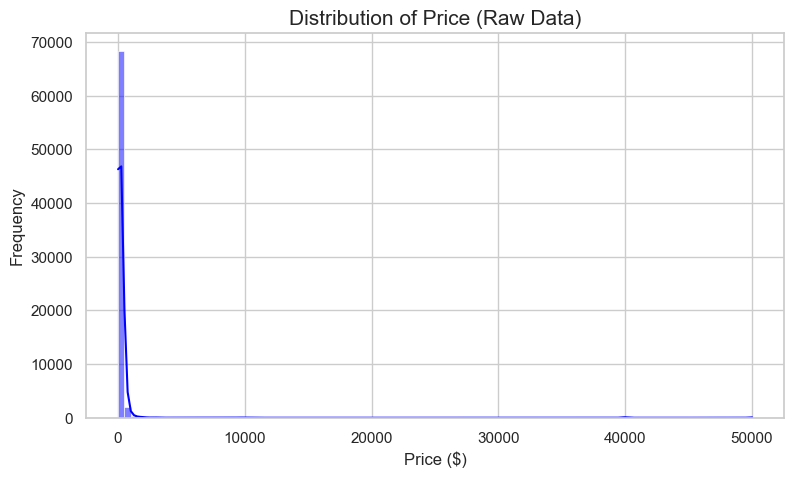

Skewness Score: 18.69


In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], bins=100, kde=True, color='blue')
plt.title('Distribution of Price (Raw Data)', fontsize=15)
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness Score: {df['price'].skew():.2f}")

#### Price Boxplot and Outliers

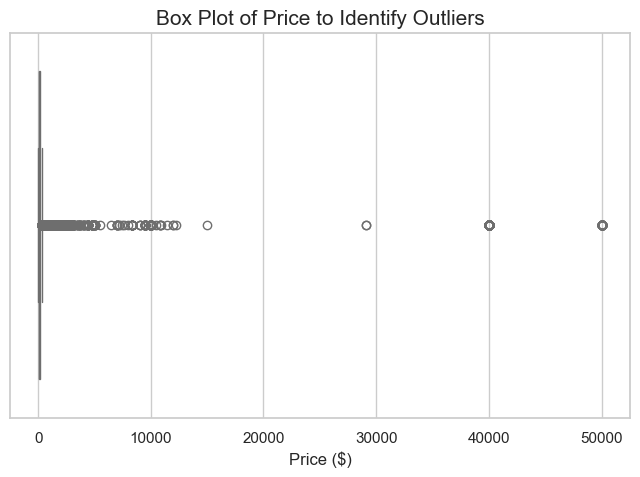

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Box Plot of Price to Identify Outliers', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

#### Price Statistical Outlier Calculation

In [10]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: ${Q1}")
print(f"Q3: ${Q3}")
print(f"Interquartile Range: ${IQR}")


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")
print(f"Total number of outlier listings: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Percentage of listings above $1,000: {(df['price'] > 1000).mean()*100:.2f}%")

Q1: $80.0
Q3: $182.0
Interquartile Range: $102.0
Lower Bound for Outliers: -73.0
Upper Bound for Outliers: 335.0
Total number of outlier listings: 5793 (7.60%)
Percentage of listings above $1,000: 1.27%


<div class="alert alert-info">
    <b>Target Price Observations:</b><br>

A quick look at the raw price distribution shows a massive long-tail problem:

* **The Core Distribution:** The middle 50% of our data is highly concentrated. Q1 sits at **\$80.00** and Q3 is **\$182.00**, giving us a really tight Interquartile Range (IQR) of just **\$102.00**. 
* **The Outlier Thresholds:** Using the standard 1.5x IQR rule, the mathematical lower bound is **-\$73.00** *(which confirms how badly the data is skewed to the right, since negative prices don't exist)*, and the upper bound is **\$335.00**.
* **The Extreme Tail:** We have 5,793 listings (7.60% of our training data) flagged as statistical outliers, with 1.27% of those listings being ultra-luxury properties priced over **\$1,000** per night. 
</div>


#### 📊 Preprocessing the Target Variable: Handling Skewness and Outliers

Before we feed our target variable (`price`) into our machine learning models, we have to address a classic dataset headache: the prices are heavily right-skewed and loaded with extreme outliers. If we skip this step, algorithms like KNN will have their distance metrics ruined, and our Neural Network will struggle to optimize its loss function because of massive gradient spikes.

<b>Our Two-Step Preprocessing Strategy</b><br>

* **Step 1: Domain Filtering (Dropping the Extreme Tail)**
  Instead of capping the outliers (which creates an artificial cluster of data that confuses models), we are just going to drop the extreme top tier (the top 5%). This completely removes the $500+ luxury anomalies from our training space, forcing the models to focus 100% of their learning capacity on the core market.

In [11]:
# Calculate percentiles
p95 = df['price'].quantile(0.95)
p99 = df['price'].quantile(0.99)
p995 = df['price'].quantile(0.995)
p998 = df['price'].quantile(0.998)

print(f"95th Percentile: ${p95:.2f}")
print(f"99th Percentile: ${p99:.2f}")
print(f"99.5th Percentile: ${p995:.2f}")
print(f"99.8th Percentile: ${p998:.2f}")

# Let's see how many listings are above the 95th percentile
outliers_95 = df[df['price'] > p95]
print(f"Number of listings above 95th percentile: {len(outliers_95)}")
outliers_99 = df[df['price'] > p99]
print(f"Number of listings above 99th percentile: {len(outliers_99)}")

95th Percentile: $452.80
99th Percentile: $1314.00
99.5th Percentile: $3082.64
99.8th Percentile: $40000.00
Number of listings above 95th percentile: 3562
Number of listings above 99th percentile: 712


In [12]:
price_cutoff = df['price'].quantile(0.95)
print(f"Defining core market: Filtering out listings above **${price_cutoff:.2f}**")

df_core_market = df[df['price'] <= price_cutoff].copy()

# See how many NaNs in target we are dealing with
nan_count = df_core_market['price'].isna().sum()
print(f"Found {nan_count} rows with a missing target price.")

# Drop ONLY the rows where the target is missing
df_core_market = df_core_market.dropna(subset=['price'])

print(f"The dataset dimension before cutoff {df.shape}")
print(f"The dataset dimension after cutoff {df_core_market.shape}")

Defining core market: Filtering out listings above **$452.80**
Found 0 rows with a missing target price.
The dataset dimension before cutoff (76255, 17)
The dataset dimension after cutoff (67663, 17)


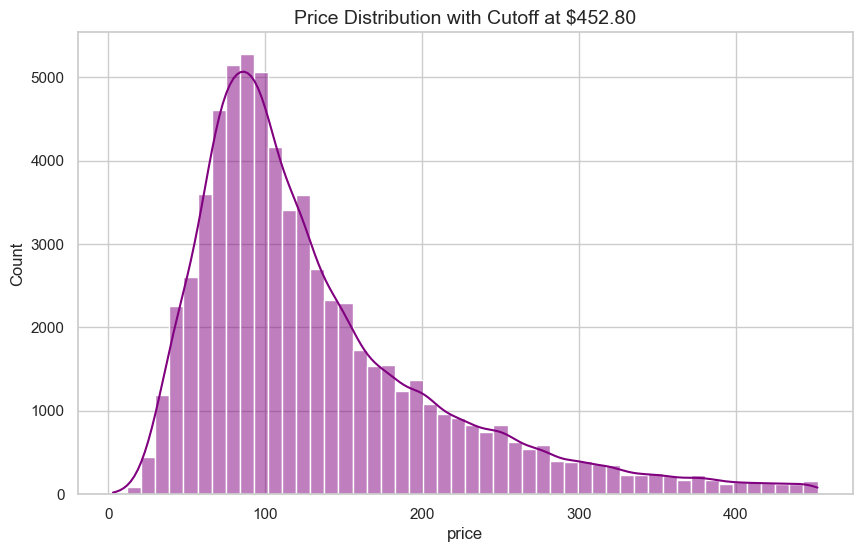

Original Skewness: 18.69
Skewness after Cutoff: 1.45


In [13]:
# Visualize the result
plt.figure(figsize=(10, 6))
sns.histplot(df_core_market['price'], bins=50, kde=True, color='purple')
plt.title(f'Price Distribution with Cutoff at ${price_cutoff:.2f}', fontsize=14)
plt.show()

# Check the new skewness
print(f"Original Skewness: {df['price'].skew():.2f}")
print(f"Skewness after Cutoff: {df_core_market['price'].skew():.2f}")

* **Step 2: Log Transformation (Fixing the Skewness)**
  Even after dropping anomaly expensive listings, real estate prices are naturally right-skewed. We will apply a log transformation (`np.log1p`) to the target variable to mathematically compress the remaining tail and force the data into a normal, bell-shaped Gaussian curve. Our models will train on these (log dollars) to keep the math stable, and during evaluation, we will just reverse the transformation using `np.expm1` to calculate our MAE and RMSE in real dollars.

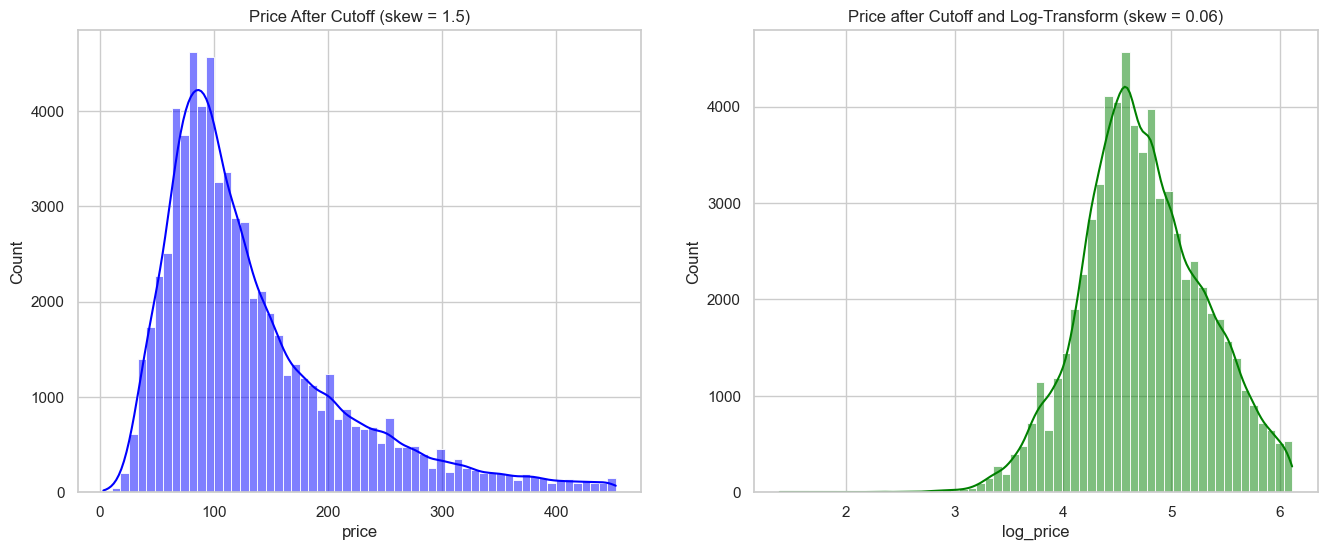

Log Price: Skewness Score: 0.06
Log Price: Statistical Upper Bound for Outliers: 6.24
Log Price: Statistical Lower Bound for Outliers: 3.25


In [14]:
df_core_market['log_price'] = np.log1p(df_core_market['price'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
sns.histplot(df_core_market['price'], bins=60, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Price After Cutoff (skew = 1.5)')

# Log Transformed
sns.histplot(df_core_market['log_price'], bins=60, kde=True, ax=axes[1], color='green')
axes[1].set_title('Price after Cutoff and Log-Transform (skew = 0.06)')

plt.show()

# Calculate Skewness and IQR-based outlier boundaries
skewness = df_core_market['log_price'].skew()
Q1 = df_core_market['log_price'].quantile(0.25)
Q3 = df_core_market['log_price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Log Price: Skewness Score: {skewness:.2f}")
print(f"Log Price: Statistical Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Log Price: Statistical Lower Bound for Outliers: {lower_bound:.2f}")

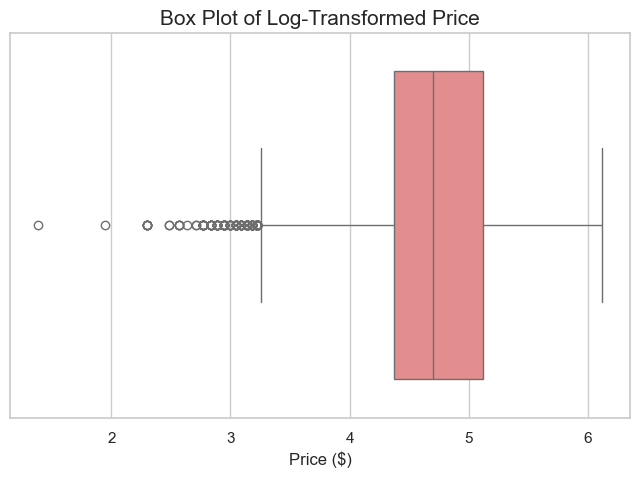

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_core_market['log_price'], color='lightcoral')
plt.title('Box Plot of Log-Transformed Price', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

### 2.3 Missing Value Analysis
Missing data can significantly bias the model. We need to see if there is a lot of thm in our dataset and set the plan on how we will treat them.

#### Visualizing and Quantifying Missingness

Top Missing Values:
                        Missing Values  Percentage (%)
review_scores_rating             10878       14.265294
price                             5030        6.596289
beds                              5029        6.594977
host_is_superhost                 3612        4.736739
bedrooms                           892        1.169759
bathrooms_text                      99        0.129828
property_type                        0        0.000000
accommodates                         0        0.000000
room_type                            0        0.000000
neighbourhood_cleansed               0        0.000000
amenities                            0        0.000000
longitude                            0        0.000000
latitude                             0        0.000000
number_of_reviews                    0        0.000000
availability_365                     0        0.000000
instant_bookable                     0        0.000000
minimum_nights                       0       

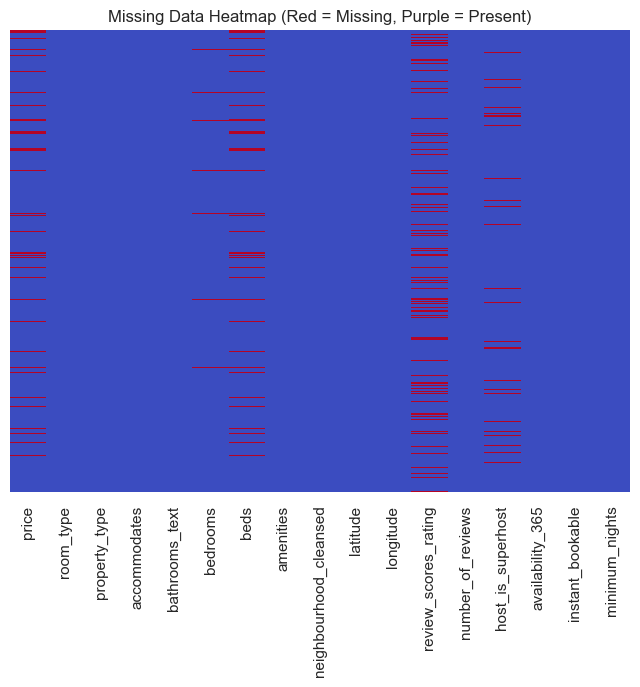

In [16]:
# Calculate percentage of missing values per column
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print("Top Missing Values:")
print(missing_df.head(20))

# Visualization: Heatmap of Missing Values
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='coolwarm')
plt.title('Missing Data Heatmap (Red = Missing, Purple = Present)')
plt.show()

### Missing Value Imputation Strategy

**1. Target Variable (`Price`)**
* **Missing Data:** ~6.6%
* **Strategy:** Drop observations.
* In supervised learning, the target variable provides the critical ground truth. Imputing these labels introduces artificial signals into the loss function that will degrade its real-world predictive accuracy. Accepting a minor 6.6% reduction in dataset size is necessary to preserve the strict integrity of our training distribution.

**2. Discrete Numeric Features (`beds`, `bedrooms`, `bathrooms`)**
* **Missing Data:** `beds` (~6.6%), `bedrooms` (~1.2%), `bathrooms` (~0.13%)
* **Strategy:** Median imputation (via pipeline).
* Because these features represent physical, discrete counts, they are highly susceptible to skew from outliers. Using mean imputation would yield unrealistic fractional values pulled toward extreme outliers. The median is statistically robust and guarantees realistic, representative values.

**3. Sentiment & Rating Features (`review_scores_rating`)**
* **Missing Data:** ~14.3%
* **Strategy:** Median imputation (via pipeline).
* This feature contains our highest rate of missingness. Assuming the main cause for this is driven by new listings that have not yet accrued reviews. Imputing with the median assigns a safe, average baseline to these properties. Filling with a value like 0 would artificially penalize new hosts by treating a lack of data as a terrible review.

**4. Categorical & Boolean Features (`host_is_superhost`)**
* **Missing Data:** `host_is_superhost` (~4.7%)
* **Strategy:** Mode (most frequent) imputation for `host_is_superhost`.
* For boolean features like the superhost flag, defaulting to the majority class (typically `False`) is the most highly probable assumption.

### 2.4 Extracting Numeric Values from Text Columns
We will use regular expressions to pull the floating-point numbers out of the bathrooms_text strings.

In [788]:
import re

def extract_bathrooms(text):
    if pd.isnull(text):
        return np.nan
    
    # Use regex to find floating point numbers or integers
    match = re.search(r'[\d\.]+', str(text))
    if match:
        return float(match.group())
    
    # Handle edge cases like "Half-bath"
    if 'half' in str(text).lower():
        return 0.5
        
    return np.nan

# Create a new numeric column
df_core_market['bathrooms'] = df['bathrooms_text'].apply(extract_bathrooms)

# Check the extraction results
print(df_core_market[['bathrooms_text', 'bathrooms']].head())

  bathrooms_text  bathrooms
2        2 baths        2.0
3         1 bath        1.0
4         1 bath        1.0
5        2 baths        2.0
6         1 bath        1.0


### 2.5 Attributes Correlation Analysis

Before constructing our predictive pipelines, we calculated the Pearson correlation coefficients between our features and the target variable (<code>log_price</code>). This helps us identify our strongest linear predictors, highlight features that might just be noise, and spot potential multicollinearity hazards that could destabilize certain algorithms.

Prepare data Preprocessor pipeline (For Correlation Matrix calculation Purposes)

In [789]:
numeric_features = [
    'log_price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'number_of_reviews', 'availability_365',
    'latitude', 'longitude'
]

categorical_features = [
    'room_type', #'property_type',
    'host_is_superhost', 'instant_bookable'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

eda_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [790]:
eda_df = df_core_market.copy()
eda_preprocessor.set_output(transform='pandas')
eda_df = eda_preprocessor.fit_transform(eda_df)
eda_df.head(3)

,num__log_price,num__accommodates,num__bedrooms,num__beds,num__bathrooms,num__review_scores_rating,num__number_of_reviews,num__availability_365,num__latitude,num__longitude,cat__room_type_Entire home/apt,cat__room_type_Hotel room,cat__room_type_Private room,cat__room_type_Shared room,cat__host_is_superhost_f,cat__host_is_superhost_t,cat__instant_bookable_f,cat__instant_bookable_t
2,-0.174924,0.366634,2.782821,0.304998,0.621931,0.100822,5.631723,0.794462,-0.507008,-0.485312,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.689539,-0.850765,-0.708453,-0.741852,-0.675206,0.178721,-0.187656,0.499194,-0.521183,-0.496171,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.299570,-0.546415,-0.708453,-0.741852,-0.675206,0.048889,-0.154528,-0.126080,1.710058,1.524493,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


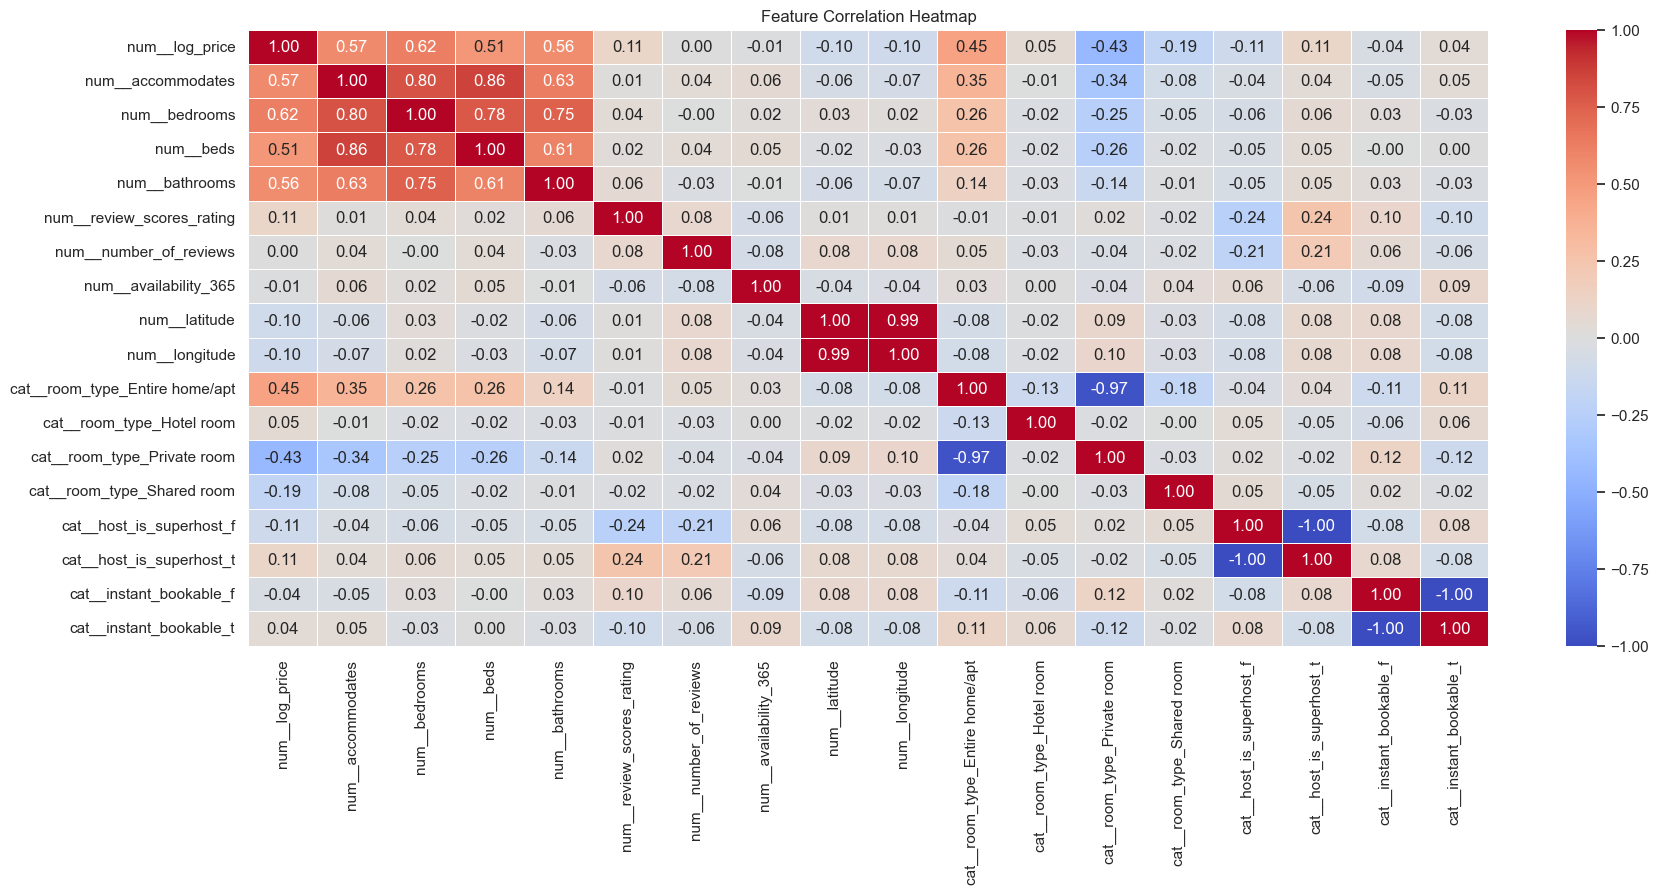

In [791]:
corr_matrix = eda_df.corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


#### 📈 Feature Correlation Insights

Based on the correlation matrix, we can categorize our dataset's features into three distinct groups regarding their predictive power and relationship with `log_price`:

1. **Attributes with High Predictive Power**<br/>
These features show a strong linear relationship with our target and will be the primary drivers of our baseline models. Unsurprisingly, physical size and privacy dominate rental-room pricing.
    * **Capacity Metrics:** `bedrooms` (0.62), `accommodates` (0.57), `bathrooms` (0.56), and `beds` (0.51) hold the highest positive correlations. 
    * **Privacy Indicators:** `room_type_Entire home/apt` has a strong positive correlation (0.45), while `room_type_Private room` has a massive negative correlation (-0.43). Guests pay a premium for not sharing space.

2. **Attributes with Low Linear Predictive Power**<br/>
Several features show correlation scores at or near zero. While Neural Networks or tree models might find complex interactions involving these variables, linear models will likely treat them as noise.
    * `number_of_reviews` (0.001) and `availability_365` (-0.01) have mathematically zero linear impact on the price.
    * `instant_bookable` status (~0.04) and `review_scores_rating` (0.10) show surprisingly weak correlations.

3. **The Geographic Attributes (Hidden Non-Linearity)**<br/>
    * `latitude` (-0.10) and `longitude` (-0.10) show very weak *linear* correlations with price. However, we know geography doesn't work in straight lines. A neighborhood boundary is highly non-linear. This mathematically justifies our later use of spatial algorithms (KNN) and tree-based ensembles (Random Forest) which can box out geographic coordinates instead of drawing a straight line through them.


Finally, the matrix reveals massive internal correlations between some of our predictor variables. Such as accommodates and beds (correlated at 0.85) and accommodates and bedrooms are correlated at 0.80. This will justify later on our decision to use the ElasticNet version of Linear Regression (which uses L1/L2 regularization to handle correlated features).

### 2.6 Spatial Analysis
By mapping our listings using their exact coordinates (Longitude vs. Latitude) and encoding the target price as a color gradient, we can visually evaluate the spatial structure of our dataset. This step is critical for determining how our machine learning models will perceive the geographic data.

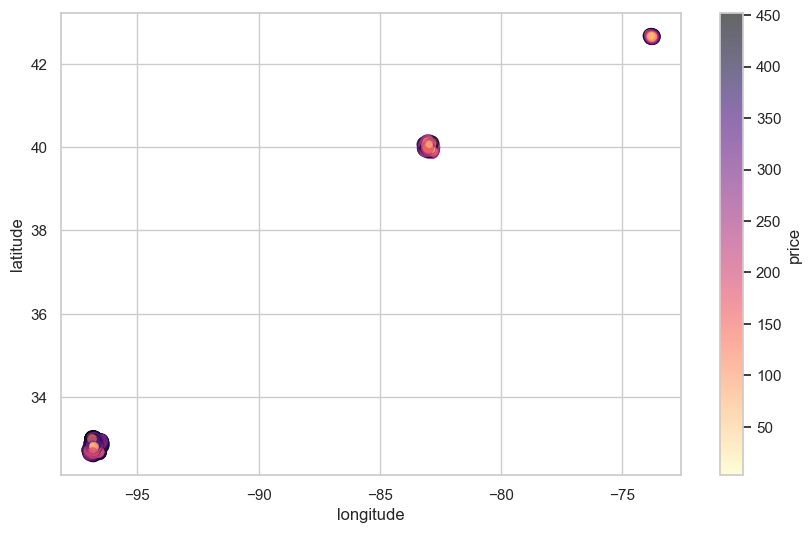

In [793]:
def plot_geographic_data(df_geo, figsize):
    # Normalize prices to the 10-150 size range (matches Seaborn's sizes=(10, 150))
    min_p, max_p = df_geo['price'].min(), df_geo['price'].max()
    
    # Prevent division by zero if all prices are identical
    if max_p == min_p:
        sizes = np.full(len(df_geo), 80)
    else:
        sizes = 10 + (df_geo['price'] - min_p) / (max_p - min_p) * (150 - 10)

    # Create the scatter plot
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        x=df_geo['longitude'],
        y=df_geo['latitude'],
        c=df_geo['price'],    # Maps color to price
        s=sizes,              # Maps size to calculated sizes
        cmap='magma_r',       # Matches palette
        alpha=0.6,
        edgecolors='none'     # Keeps dots smooth like Seaborn
    )

    # Add labels and a colorbar for 'hue' interpretation
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    cbar = plt.colorbar(scatter)
    cbar.set_label('price')

    plt.show()

plot_geographic_data(df_core_market,(10, 6))

#### Zooming to one specific area

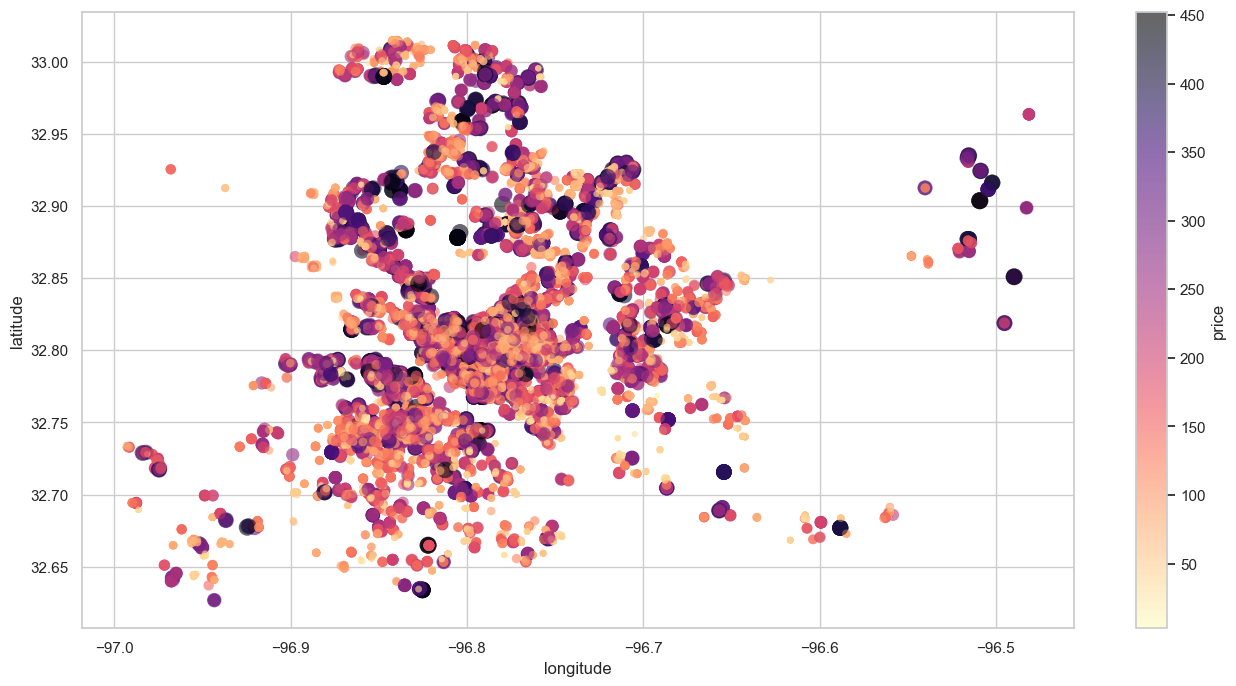

In [794]:
df_filtered_state = df_core_market[df_core_market['latitude']<=34]
plot_geographic_data(df_filtered_state,figsize=(16, 8))



#### Key Geographic Findings

* Our dataset is not a continuous, even spread across a wide region. Instead, it is highly localized into three distinct, isolated geographic hubs (representing specific states or cities). 
* Within each of these three clusters, we can see a tight overlapping of both high-priced listings (dark purple/black) and lower-priced listings (light yellow/orange). This indicates that the macro-location (which city you are in) is not enough to predict price.

<div class="alert alert-block alert-success">
<b>💡 Our Expectations based on these observations</b><br>
For standard Linear Regression, the math would attempt to draw a continuous plane across thousands of miles of empty space, leading to terrible predictions. However, distance-based models (like <b>KNN</b>) and other models (like <b>Random Forest</b>) will perform a little bit better with such spatial distribution.
</div>

### 2.7 Amenities Analysis
The specific amenities offered define the guest experience and justify a premium rate. In this section, We will preprocess the raw, unstructured amenity data into distinct binary features.

In [795]:
df['amenities'].head(3)

0    ["Hangers", "Cooking basics", "Private entranc...
1    ["Hot water", "Exterior security cameras on pr...
2    ["Carbon monoxide alarm", "Extra pillows and b...
Name: amenities, dtype: object

Parse amenities string representation of list to actual python list


In [796]:
def parse_amenities(x):
    try:
        # Handling different formats of stringified lists
        x = x.replace('{', '[').replace('}', ']')
        return ast.literal_eval(x)
    except:
        return []


# Apply Parsing
df_core_market['amenities_list'] = df_core_market['amenities'].apply(parse_amenities)

# Flatten the list of lists into one giant list of amenities
all_amenities = [item for sublist in df_core_market['amenities_list'] for item in sublist]
amenity_counts = Counter(all_amenities)

* List top 15 frequent amenities
At the end of this section Our goal is We need to know which amenities appear most frequently. If "Wifi" appears in 99% of listings, it won't be a useful rule (it has no discriminative power).

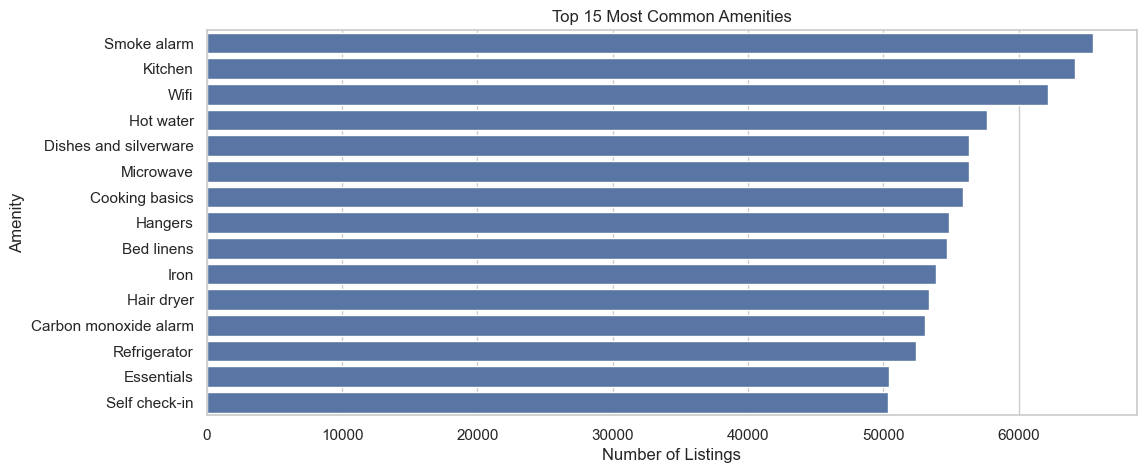

In [797]:
df_amenity_counts = pd.DataFrame(amenity_counts.most_common(15), columns=['Amenity', 'Count'])

plt.figure(figsize=(12, 5))
sns.barplot(y='Amenity', x='Count', data=df_amenity_counts)
plt.title('Top 15 Most Common Amenities')
plt.xlabel('Number of Listings')
plt.show()

#### Cleaning Amenities
We need to parse amenties into items and to clean the amenties from duplicate keywords as much as pssoible (tv, telvision) or (wifi,internet) ..etc 

In [798]:
def clean_amenity_list(amenity_list):
    """
    Standardizes common messy amenity strings into simple categories.
    Example: "50 inch HDTV with Netflix" -> ["TV", "Netflix"]
    """
    cleaned_list = []
    
    for item in amenity_list:
        item_str = str(item).lower()

        for word in ['yes','\n','\t']:
            if word in item_str:
                item_str = item_str.replace(word,"")
                
        # Handle TV & Streaming stuff
        if 'tv' in item_str or 'cable' in item_str:
            cleaned_list.append('TV')
            if any(x in item_str for x in ['netflix', 'hulu', 'hbo', 'disney', 'apple tv', 'amazon prime']):
                cleaned_list.append('Streaming Service')
        
        # Handle Internet
        elif 'wifi' in item_str or 'internet' in item_str:
            cleaned_list.append('Wifi')
            
        # Handle Climate
        elif 'air conditioning' in item_str or 'ac ' in item_str:
            cleaned_list.append('Air conditioning')
        elif 'heating' in item_str or 'heater' in item_str:
            cleaned_list.append('Heating')
            
        # Handle Kitchen specifics
        elif 'coffee' in item_str or 'espresso' in item_str:
            cleaned_list.append('Coffee Maker')
        elif 'refrigerator' in item_str or 'fridge' in item_str:
            cleaned_list.append('Refrigerator')
        elif 'stove' in item_str or 'oven' in item_str:
            cleaned_list.append('Stove')
            
        # Handle "Long Junk Strings"
        # If a string is > 35 chars and didn't match the keywords above, it's likely noise.
        elif len(item_str) > 35 or 'wine' in item_str:
            continue # Skip it (e.g., "paid parking off premises...")
            
        # Keep short, clean items (e.g., "Pool", "Gym", "Iron")
        else:
            # Capitalize first letter for consistency
            cleaned_list.append(item_str.title())
            
    # Remove duplicates (e.g., if "TV" was added twice from the same string)
    return list(set(cleaned_list))


# Apply Cleaning
df_core_market['amenities_list'] = df_core_market['amenities_list'].apply(clean_amenity_list)
# Create a simple numeric feature: How many amenities does the host offer?
df_core_market['amenity_count'] = df_core_market['amenities_list'].apply(len)

print(df_core_market[['amenities_list', 'amenity_count']].head())

                                      amenities_list  amenity_count
2  [Smoke Alarm, Air conditioning, Conditioner, S...             45
3  [Smoke Alarm, Hot Water Kettle, Air conditioni...             47
4  [Smoke Alarm, Air conditioning, Conditioner, S...             29
5  [Smoke Alarm, Exercise Equipment, Fire Extingu...             15
6  [Smoke Alarm, Air conditioning, Self Check-In,...             20


In [799]:
# Filter out extreme outliers (e.g., top 1% of prices)
print(f"Correlation between Amenity Count and Price: {df_core_market['log_price'].corr(df_core_market['amenity_count']):.2f}")

Correlation between Amenity Count and Price: 0.28


In [800]:
print("Sample of Amenities After Cleaning:\n", df_core_market['amenities_list'].iloc[0][:20])

Sample of Amenities After Cleaning:
 ['Smoke Alarm', 'Air conditioning', 'Conditioner', 'Self Check-In', 'Outdoor Furniture', 'Dishes And Silverware', 'First Aid Kit', 'Refrigerator', 'Heating', 'Shampoo', 'Carbon Monoxide Alarm', 'Shower Gel', 'Free Parking On Premises', 'Wifi', 'Patio Or Balcony', 'Essentials', 'Coffee Maker', 'Cleaning Products', 'Body Soap', 'Stove']


#### One-Hot encode the amenities
Now we have to transform the amenities_list to One-Hot encoded matrix which the learning algorithms would actually use. 
This process turned a single column of amenities_list into a high-dimensional sparse matrix. This is critical because it allows our models—especially the Neural Network and ElasticNet—to assign specific weights to each amenity. Without this step, the model would have no way to quantify how much "Air Conditioning" or a "Private Entrance" actually adds to the nightly price.

In [801]:
# One-Hot Encoding for the cleaned amenities
mlb = MultiLabelBinarizer()
amenities_ohe = mlb.fit_transform(df_core_market['amenities_list'])
df_amenities = pd.DataFrame(amenities_ohe, columns=mlb.classes_, index=df_core_market.index)
df_amenities.head(3)

,Body Soap,Conditioner,Dove Body Soap,Shampoo,(Generic) Conditioner,(Generic) Shampoo,100% Vegan & Cruelty-Free Body Soap,100% Vegan & Cruelty-Free Shampoo,100% Vegan Body Soap,100% Vegan Conditioner,...,Yamaha Sound System With Aux,Yamaha Bluetooth Sound System,Yamaha Sound System With Aux,Zeroderm Fragrance Free Body Soap,Zogics Organics Body Soap,Zogics Organics Conditioner,Zogics Organics Shampoo,“Everyone” Brand Soap Body Soap,“Everyone” Soap Body Soap,“Everyone” Soap/Shampoo Shampoo
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Amenities Pruning: Filtering for Predictive Power
Now that we have converted our text into binary columns, we face a new challenge: The Curse of Dimensionality. We have generated a massive matrix of features (1101 columns), but not all of them are mathematically useful for predicting price. In the following code, we calculate the "support" (frequency) of each amenity across the dataset to identify and prune two types of unhelpful features:

* The "Too Common" (>98%): If almost every listing has an amenity (like standard "Wifi"), it offers near-zero variance. If everyone has it, the model cannot use it to differentiate a $50 room from a $500 room.

* The "Too Rare" (<5%): If an amenity appears in fewer than 5% of our listings, it is too sparse for the model to learn a reliable, repeatable pattern. Keeping these rare columns only adds computational noise and increases the risk of overfitting.

By dropping these extreme ends of the spectrum, we efficiently prune our dataset down to a the most important set of amenities.

In [802]:
# Feature Pruning
amenity_support = df_amenities.mean()
# now likely lower the 'upper_limit' because "Wifi" will be even more common now that we fixed the spelling variations
too_common = amenity_support[amenity_support > 0.98].index.tolist() 
too_rare = amenity_support[amenity_support < 0.05].index.tolist()
cols_to_drop = too_common + too_rare

df_amenities_clean = df_amenities.drop(columns=cols_to_drop)

print(f"Final Cleaned Features(Amenities) Count: {df_amenities_clean.shape[1]}")

df_amenities_clean.head(3)

Final Cleaned Features(Amenities) Count: 89


,Babysitter Recommendations,Backyard,Baking Sheet,Barbecue Utensils,Bathtub,Bbq Grill,Bed Linens,Blender,Board Games,Body Soap,...,Single Level Home,Smart Lock,Smoke Alarm,Stove,Streaming Service,Sun Loungers,TV,Toaster,Trash Compactor,Washer
2,0,1,0,0,1,0,1,0,0,1,...,1,0,1,1,0,0,1,0,0,0
3,0,0,1,0,1,0,1,0,0,1,...,1,0,1,1,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,1,1,0,0,0,1,0,0,0


Our amenities list reduced to <b>89 features</b> now. 

let us now concatenate the pruned 89 hot-encoded amenities data-frame with our original df_core_market

In [803]:
df_final = df_core_market.drop(columns=['price','amenities_list','amenities'])

# Merge the main dataframe and the processed amenities dataframe side-by-side
df_final = pd.concat([df_final, df_amenities_clean], axis=1)

# Extract the names of all the amenity columns
amenity_columns = df_amenities_clean.columns.tolist()

print(f"Successfully added {len(amenity_columns)} amenity features to the dataset.")

Successfully added 89 amenity features to the dataset.


## 3. Learning

### 3.1 Prepare Data perprocessor pipeline

The Preprocessor Pipeline is the automated "factory" that cleans, scales, and transforms our raw data into a refined numerical format that the algorithms can actually understand.

Why We Use a Pipeline Instead of Manual Cleaning?

* Our dataset contains a mix of different data types that each require a unique mathematical treatment. The pipeline allows us to apply different rules to different "branches" of our data simultaneously:
    * **Numerical Features:** Features like `bedrooms` or `latitude` are passed through an **Imputer** (to fill missing values) and a **StandardScaler** (to ensure all numbers are on the same scale, preventing a feature with large numbers from oppress others).
    * **Categorical Features:** Text-based features like `room_type` and `property_type` are sent through a **One-Hot Encoder** to turn strings into binary math flags.

* If we calculated the "mean" or "scale" of our data using the *entire* dataset before splitting, the model would effectively "peek" at the test set answers during training. By wrapping everything in a pipeline, we ensure that the model only learns the transformation rules from the **Training Set** and simply applies them to the **Test Set**, keeping our evaluation honest and realistic.

In [804]:
# Update Numeric Features to include the 89+ amenity columns
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 'amenity_count', 
    'review_scores_rating', 'number_of_reviews', 'availability_365',
    'latitude', 'longitude', 'minimum_nights'
] + amenity_columns 

# Categorical Features remain exactly the same
categorical_features = [
    'room_type', 'property_type', #'neighbourhood_cleansed', 
    'host_is_superhost', 'instant_bookable'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Finalize the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

Split the dataset into two separate Training (<b>80%</b>) and Testing (<b>20%</b>) sets, and separate the predicator attributes (X) from the target attribute (Y):  

In [805]:
X = df_final[numeric_features + categorical_features]
y = df_final['log_price']

# Perform the Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully splitted and ready for training.")
print(f"X_train shape: {X_train.shape}.")
print(f"Y_train shape: {y_train.shape}.")
print(f"X_test shape: {X_test.shape}.")
print(f"Y_test shape: {y_test.shape}.")
print(f"Verify NaNs in y: {y.isna().sum()}")

Data successfully splitted and ready for training.
X_train shape: (54130, 104).
Y_train shape: (54130,).
X_test shape: (13533, 104).
Y_test shape: (13533,).
Verify NaNs in y: 0


### Model Tracking
We initialize a global `models` dictionary to store each tuned estimator alongside its evaluation metrics. This will allow for a comprehensive performance comparison at the end of the pipeline.

In [806]:
models = {}

### 3.2 Declare tune_regressor function and other utilities functions
The <code>tune_regressor</code> function is our training and grid-search controller. Instead of manually guessing which hyperparameters might work best for our models, this function uses <b>GridSearchCV</b> to systematically hunt for the most accurate version of any given algorithm. This function streamlines that process by performing three critical tasks in a single call.
Once the search is complete, the function automatically identifies the best version of the model and provides us with the **best_params_**,  **best_score_** and other metrics measures like **MAE, RMSE and R2**.

By wrapping this logic into a reusable function, we’ve created a standardized "benchmark" for every model in our project. Whether we are tuning a simple <b>ElasticNet</b> or a complex <b>Random Forest</b>, the <code>tune_regressor</code> function ensures that every algorithm gets the same fair, mathematically treatment.

In [807]:
def tune_regressor(model_name, X_train, y_train, X_test, y_test, cv=5) -> Pipeline: 
    print(f"Learning and tuning the {model_name} started ...")

    model_dict = models[model_name]

    # Standard scikit-learn Pipeline 
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # Maps categorical and numeric handling
        ('regressor', model_dict['model'])            # Your algorithm (e.g., RandomForest, XGBoost)
    ])

    # Grid Search setup
    model_dict['grid_search'] = grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=model_dict['param_grid'],
        cv=cv,
        scoring='neg_mean_absolute_error', # Optimize for lowest dollar error
        n_jobs=-1,
        verbose=2
    )

    print("Starting Grid Search... Go grab a coffee, this will take a while!")
    grid_search.fit(X_train, y_train)

    print("\n--- Tuning Complete ---")
    print(f"Best Hyperparameters Found:\n{grid_search.best_params_}")
    
    best_cv_mae = -grid_search.best_score_
    print(f"Best Cross-Validation MAE (Log Scale): {best_cv_mae:.4f}")
    model_dict['best_cv_mae'] = best_cv_mae
    model_dict['best_tuned_pipeline'] =  best_tuned_pipeline = grid_search.best_estimator_

    # Make predictions with the tuned model
    log_y_pred = best_tuned_pipeline.predict(X_test)

    # Reverse the Log Transformation for interpretable business metrics
    real_y_test = np.expm1(y_test)
    real_y_pred = np.expm1(log_y_pred)

    # Calculate Regression Metrics
    model_dict['mae'] = mae = mean_absolute_error(real_y_test, real_y_pred)
    model_dict['rmse'] = rmse = np.sqrt(mean_squared_error(real_y_test, real_y_pred))
    model_dict['r2'] = r2 = r2_score(real_y_test, real_y_pred)

    print(f"\n--- Best {model_name} Performance (Real Dollars) ---")
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
    print(f"R-squared (R2): {r2:.4f}")

    # Plotting Actual vs Predicted
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=real_y_test, y=real_y_pred, alpha=0.5, color='blue')
    
    # Draw the perfect prediction diagonal line
    max_val = max(real_y_test.max(), real_y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    plt.title(f"Actual vs Predicted Prices: Best {model_name}")
    plt.ylabel("Predicted Price ($)")
    plt.xlabel("Actual Price ($)")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.show()
    
    print(f"Learning and tuning the {model_name} completed.")
    #return best_tuned_pipeline

In [ ]:
def get_model_training_validating_time(model_name, _print=True):

    grid_search = models[model_name]['grid_search']
    results = pd.DataFrame(grid_search.cv_results_)
    n_folds = grid_search.cv

    # Calculate totals
    total_fit_time_seconds = results['mean_fit_time'].sum() * n_folds
    total_score_time_seconds = results['mean_score_time'].sum() * n_folds
    grand_total_seconds = total_fit_time_seconds + total_score_time_seconds

    if _print:
        print(f"Total time spent TRAINING (Fitting): {total_fit_time_seconds:.2f} seconds")
        print(f"Total time spent PREDICTING (Scoring): {total_score_time_seconds:.2f} seconds")
        print(f"Grand Total Algorithm Processing Time: {grand_total_seconds:.2f} seconds")
        
    return total_fit_time_seconds, total_score_time_seconds, grand_total_seconds

#### declare  draw_training_vs_validation_error_curve

The <code>draw_training_vs_validation_error_curve</code> function acts as a high-level diagnostic tool that plots model error against the <b>Training Sample Size</b> on the x-axis. By observing how the training and validation error curves evolve as we feed the model more listings—moving from a small subset to the full dataset—we can mathematically identify whether our tuned model is suffering from <b>high variance</b> (overfitting, visible as a persistent gap between the lines) or <b>high bias</b> (underfitting, where both curves flatten out at an unacceptably high error). This visualization is crucial for determining if our model has reached "convergence," proving whether we need more data to improve our $R^2$ or if we have already squeezed all the predictive power possible out of our current features.

In [809]:
def draw_training_vs_validation_error_curve(name):
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    plt.figure(figsize=(9, 5))
        
    print(f"Calculating learning curve for {name}...")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=models[name]['best_tuned_pipeline'],
        X=X_train, 
        y=y_train,
        train_sizes=np.linspace(0.1, 1, 9), # 8 points to keep calculation time reasonable
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    train_error = 1.0 - np.mean(train_scores, axis=1)
    test_error = 1.0 - np.mean(test_scores, axis=1)

    # Plot Training Error (Solid Line)
    plt.plot(train_sizes, train_error, 
            color=colors[0], marker='o', linestyle='-', 
            label=f'{name} (Train)')
    
    # Plot Validation Error (Dashed Line)
    plt.plot(train_sizes, test_error, 
            color=colors[1], marker='s', linestyle='--', 
            label=f'{name} (Validation)')

    plt.title('Training vs. Validation Errors', fontsize=14)
    plt.xlabel('Number of Training Samples', fontsize=12)
    plt.ylabel('Error', fontsize=12)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

### 3.3 Decision Tree

Learning and tuning the Decision Tree started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 15}
Best Cross-Validation MAE (Log Scale): 0.1579

--- Best Decision Tree Performance (Real Dollars) ---
Mean Absolute Error (MAE): $21.14
Root Mean Squared Error (RMSE): $36.36
R-squared (R2): 0.7926


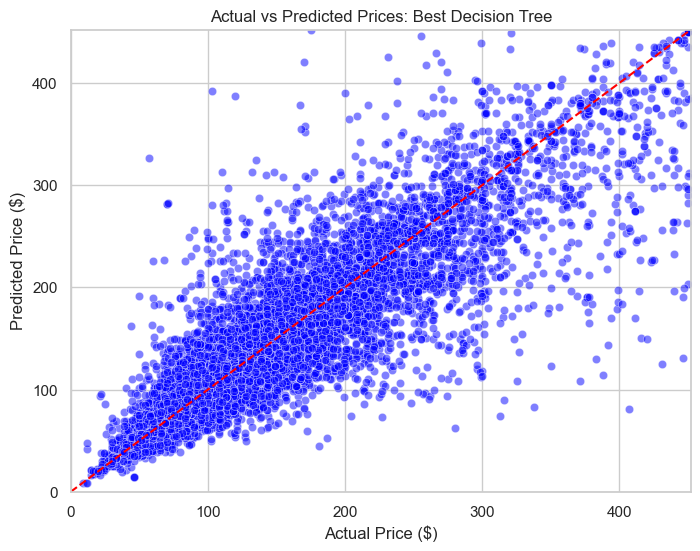

Learning and tuning the Decision Tree completed.


In [881]:
Decision_Tree_Model = 'Decision Tree'

models[Decision_Tree_Model] =  {
    'model': DecisionTreeRegressor(random_state=42),
    'best_tuned_pipeline': None,
    'param_grid': {
        'regressor__max_depth': [10, 20, 30, None],
        'regressor__min_samples_split': [2, 5, 15],
        'regressor__min_samples_leaf': [1, 5, 15]
    }
}

tune_regressor(
    model_name=Decision_Tree_Model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5
)

#### Training and Validation Time

In [886]:
results = get_model_training_validating_time(Decision_Tree_Model)

Total time spent TRAINING (Fitting): 627.01 seconds
Total time spent PREDICTING (Scoring): 20.49 seconds
Grand Total Algorithm Processing Time: 647.50 seconds


#### Learning Curve
Here we are Plotting the error against the number of training samples


Calculating learning curve for Decision Tree...


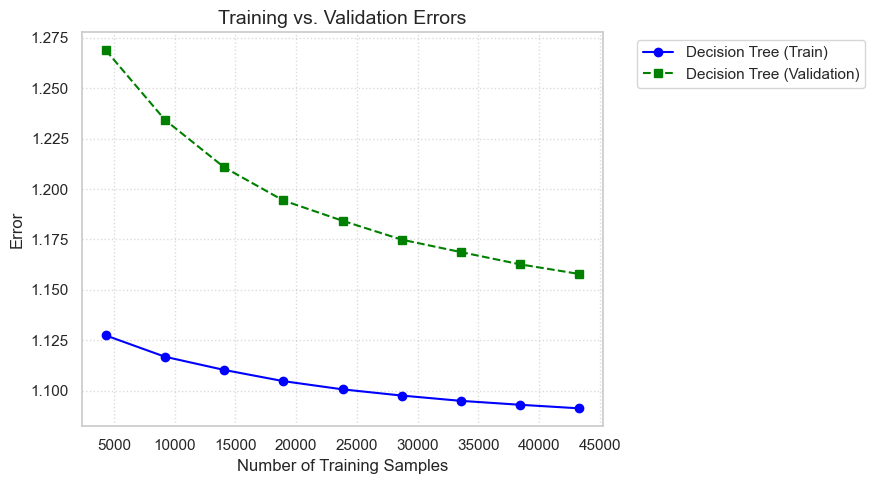

In [812]:
draw_training_vs_validation_error_curve(Decision_Tree_Model)

### Decision Tree Results

Our baseline Decision Tree yielded encouraging results. 

**Mean Absolute Error (MAE)** ($21.14): 
This is our most interpretable business metric. On average, our model's predicted nightly rate is off by only $21.14. This level of precision for this baseline model can provide highly actionable, reliable pricing for standard market hosts.

**Root Mean Squared Error (RMSE)** ($36.36): 
Because RMSE mathematically penalizes larger errors more heavily than MAE, the gap between these two numbers provides valuable context. It indicates that while the model is highly accurate for the vast majority of listings, there are still occasional properties where the algorithm misses by a wider margin.

**R-squared** (0.7926): 
The model successfully explains 79% of the variance in the target price. In the context of hospitality—where pricing is often heavily influenced by subjective human decisions and unstructured text—an R-squared approaching 0.80 indicates an exceptionally strong mathematical signal from our geographic coordinates and binary amenity features.

These metrics strongly validate our preprocessing pipeline. By removing the mathematical distortion of the ultra-luxury market (dropping the top 5%) and converting our target variable into a normal distribution, we empowered a single Decision Tree to successfully decode the pricing structure of the core market.

## 3.4 K-Nearest Neighbors (KNN)

Learning and tuning the KNN started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 12 candidates, totalling 120 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__n_neighbors': 5, 'regressor__weights': 'distance'}
Best Cross-Validation MAE (Log Scale): 0.1344

--- Best KNN Performance (Real Dollars) ---
Mean Absolute Error (MAE): $18.53
Root Mean Squared Error (RMSE): $32.59
R-squared (R2): 0.8333


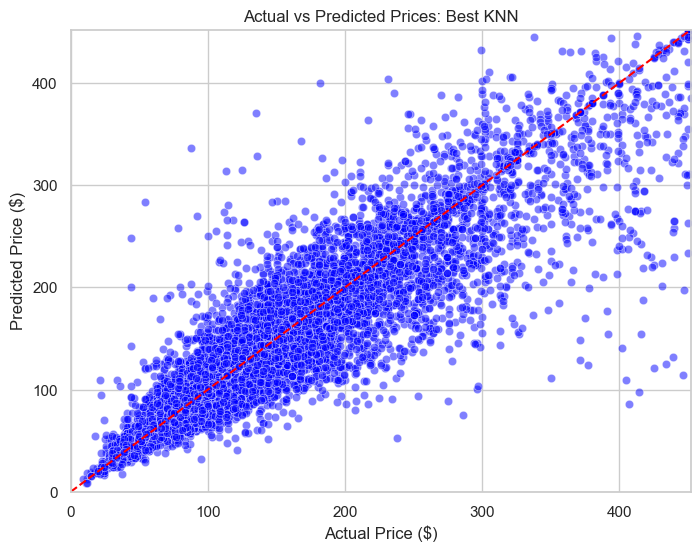

Learning and tuning the KNN completed.


In [ ]:
KNN_Model = 'KNN'

models[KNN_Model] =  {
    'model': KNeighborsRegressor(n_jobs=-1), 
    'best_tuned_pipeline': None,
    'param_grid': {
        'regressor__n_neighbors': [5, 7, 9, 13, 15, 21],
        'regressor__weights': ['uniform', 'distance']
    }
}

tune_regressor(
    model_name=KNN_Model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5
)

#### Training and Validation Time

In [814]:
results = get_model_training_validating_time(KNN_Model)

Total time spent TRAINING (Fitting): 158.66 seconds
Total time spent PREDICTING (Scoring): 610.51 seconds
Grand Total Algorithm Processing Time: 769.17 seconds


#### Learning Curve
Here we are Plotting the error against the number of training samples


Calculating learning curve for KNN...


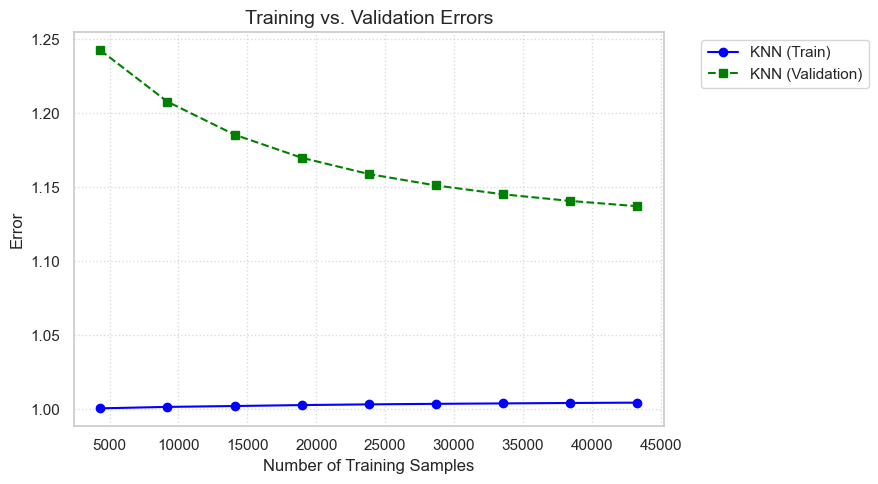

In [815]:
draw_training_vs_validation_error_curve(KNN_Model)

### K-Nearest Neighbors (KNN) Results
Following our baseline Decision Tree, we trained a K-Nearest Neighbors (KNN) regressor. Because pricing in rental-market is inherently spatial, this distance-based algorithm yielded a significant leap in predictive power.

**Mean Absolute Error (MAE)** - $18.53: We reduced our average prediction error to just $18.53 per night.

**Root Mean Squared Error (RMSE)** - $32.59: this model shaved around $4 off our RMSE compared to the baseline model. This indicates that KNN is not only better at predicting the average listing but is also making fewer "large magnitude" mistakes.

**R-squared** (0.8333): Breaking the 0.80 threshold in hospitality pricing is a major milestone, proving that our cleaned feature space (specifically geographic coordinates combined with binary amenities) perfectly aligns with distance-based learning logic.

The performance of KNN validates our earlier decision to use Domain Filtering (dropping the top 5% of outliers). Because distance-based algorithms are highly sensitive to extreme spatial anomalies and synthetic data, providing KNN with a clean, naturally distributed core market allowed it to accurately map the localized "neighborhood physics" of room-rental market pricing.

## 3.5 Linear Regression (ElasticNet)

Learning and tuning the ElasticNet started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.25}
Best Cross-Validation MAE (Log Scale): 0.2558

--- Best ElasticNet Performance (Real Dollars) ---
Mean Absolute Error (MAE): $34.86
Root Mean Squared Error (RMSE): $53.60
R-squared (R2): 0.5492


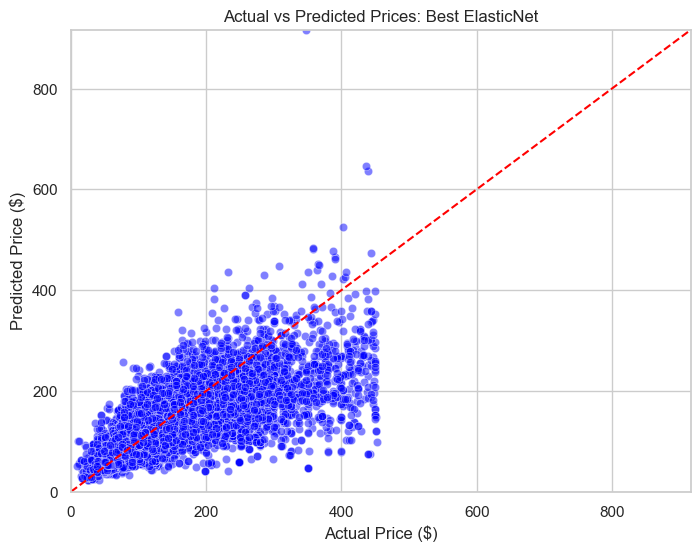

Learning and tuning the ElasticNet completed.


In [846]:
ElasticNet_Model = 'ElasticNet'

models[ElasticNet_Model] = {
    'model': ElasticNet(random_state=42), 
    'best_tuned_pipeline': None,
    'param_grid': {
        # Alpha: The overall strength of the regularization penalty.
        # 0.0 is standard Linear Regression. Higher values heavily penalize the model 
        # to prevent overfitting, shrinking feature weights closer to zero.
        'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
        # Values in between represent the true "ElasticNet" blend.
        'regressor__l1_ratio': [0.25, 0.5, 0.75]
    }
}

tune_regressor(
    model_name=ElasticNet_Model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5
)

#### Training and Validation Time

In [847]:
results = get_model_training_validating_time(ElasticNet_Model)

Total time spent TRAINING (Fitting): 506.60 seconds
Total time spent PREDICTING (Scoring): 12.01 seconds
Grand Total Algorithm Processing Time: 518.61 seconds


#### Learning Curve
Here we are Plotting the error against the number of training samples


Calculating learning curve for ElasticNet...


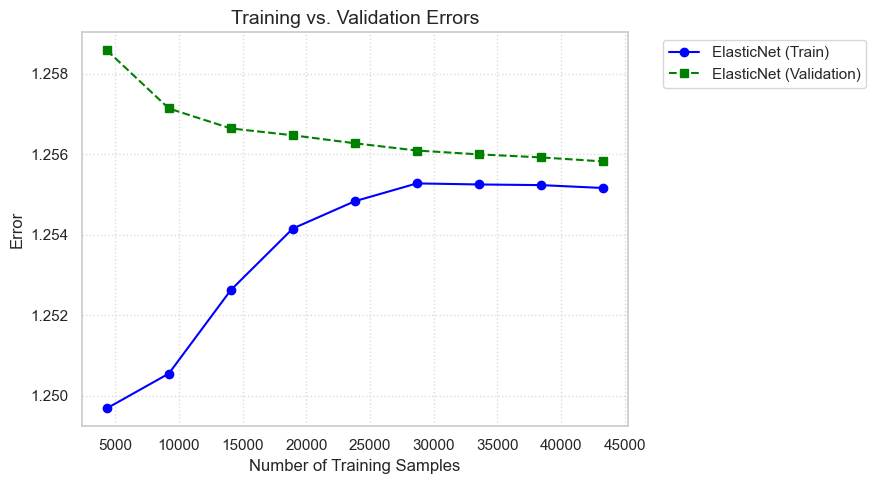

In [848]:
draw_training_vs_validation_error_curve(ElasticNet_Model)

### Linear Regression Results (ElasticNet)
To mathematically validate the need for complex, non-linear machine learning algorithms, we trained an ElasticNet Linear Regression model on our cleaned dataset. As expected, the performance dropped significantly.

**Mean Absolute Error (MAE)** - $34.86: The average prediction error more almost doubled compared to previous models.

**R-squared (0.5492)**: ElasticNet could only explain 54.9% of the variance in pricing, much less than the explanatory power of all other models. This proves that rental-market pricing is highly non-linear.

We think that the fundamental reason for this underperformance is our geographic data (latitude and longitude). Linear models assume a constant, straight-line relationship between features and the target. They cannot map the complex, uneven spatial boundaries of real estate, whereas distance and tree-based models map these spatial thresholds effortlessly.

The failure of the ElasticNet model proves that simple linear correlations are insufficient for hospitality pricing, fully justifying the computational expense of deploying more complex better performing models.

## 3.6 Random Forest

Learning and tuning the RandomForest started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}
Best Cross-Validation MAE (Log Scale): 0.1304

--- Best RandomForest Performance (Real Dollars) ---
Mean Absolute Error (MAE): $17.69
Root Mean Squared Error (RMSE): $30.13
R-squared (R2): 0.8575


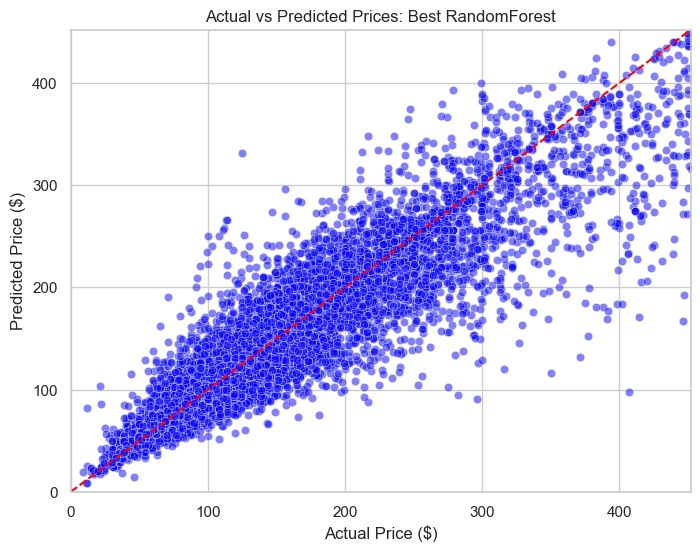

Learning and tuning the RandomForest completed.


In [ ]:
RandomForest_Model = 'RandomForest'

models[RandomForest_Model] = {
    'model': RandomForestRegressor(random_state=42, n_jobs=-1),
    'best_tuned_pipeline': None,
    'param_grid': {
        # Trees take longer to train, so we keep the grid slightly smaller
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_leaf': [1, 2, 4], 
    }
}

tune_regressor(
    model_name = RandomForest_Model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5,
)

#### Training and Validation Time

In [820]:
results = get_model_training_validating_time(RandomForest_Model)

Total time spent TRAINING (Fitting): 14738.29 seconds
Total time spent PREDICTING (Scoring): 1108.77 seconds
Grand Total Algorithm Processing Time: 15847.05 seconds


#### Learning Curve
Here we are Plotting the error against the number of training samples


Calculating learning curve for RandomForest...


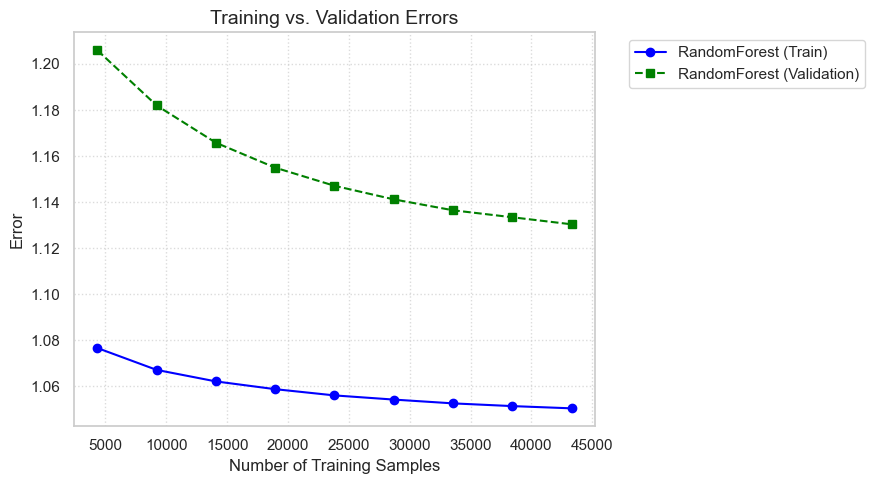

In [821]:
draw_training_vs_validation_error_curve(RandomForest_Model)

#### Key Observations from the Curve

1. There is a clear, persistent gap between the training error (~1.05) and the validation error (~1.13) across the entire plot. Because Random Forests are highly complex, they naturally tend to memorize training data. This gap indicates **moderate overfitting**. 

2. The Model is Data Hungry: Despite the gap, this is a very healthy learning curve. As the number of training samples increases from 5,000 to 45,000, the validation error steadily and continuously drops, and that if we feed the model with more data, the model may achieve a better performance.

### Random Forest Results
This approach yielded our best performance metrics across the board.

**Mean Absolute Error (MAE)** - $17.69: We have driven our average prediction error down to a highly precise $17.69. At this level of accuracy, the model is capable of providing hosts with highly reliable, automated pricing recommendations.

**Root Mean Squared Error (RMSE)** - $30.13: The Random Forest successfully shaved another $2.46 off the RMSE compared to KNN. This proves the power of ensemble learning: when one tree makes a drastically wrong prediction on a complex listing, the thousands of other trees correct it.

**R-squared (0.8575)**: The model now explains a remarkable 85.7% of the variance in the prices.


### Extracting and Plotting Feature Importances
Extracting feature importances is one of the most rewarding parts of the machine learning process. It telling us exactly what the algorithm learned about the real-world room-rental market.

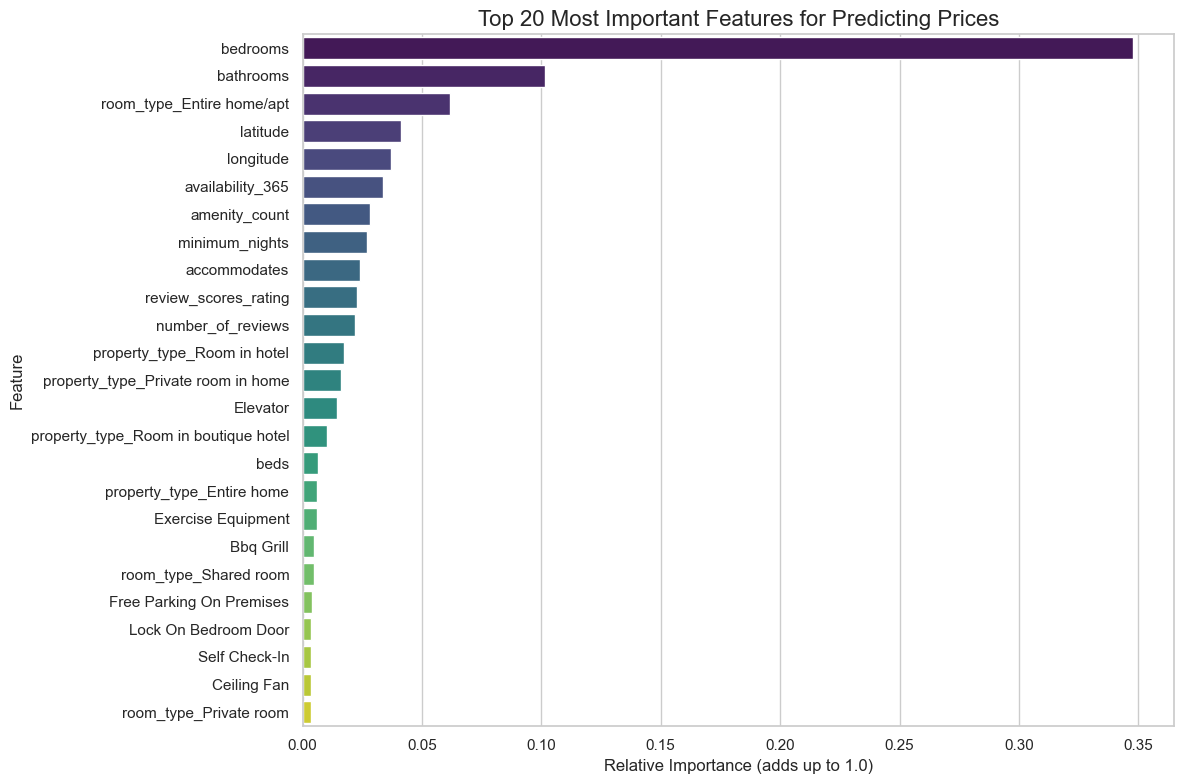


--- Top 10 Drivers of the Price ---
                  Feature  Importance
                 bedrooms    0.347540
                bathrooms    0.101500
room_type_Entire home/apt    0.061755
                 latitude    0.041263
                longitude    0.037017
         availability_365    0.033846
            amenity_count    0.028432
           minimum_nights    0.026874
             accommodates    0.024261
     review_scores_rating    0.022871


In [ ]:
# Because we used a Scikit-learn Pipeline with a ColumnTransformer, 
# we have to extract the feature names directly from the preprocessor step 
# so that it correctly accounts for all the new One-Hot Encoded neighborhood and property type columns.

# Extract the best tuned Random Forest pipeline from your dictionary
rf_pipeline = models['RandomForest']['best_tuned_pipeline']

# Extract the preprocessor and the actual model from the pipeline
preprocessor = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['regressor']

# Get the names of all the One-Hot Encoded categories + numerical attributes
feature_names = preprocessor.get_feature_names_out()

# Clean up the scikit-learn prefixes ('num__' and 'cat__') for a cleaner chart
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(25), palette='viridis')
plt.title('Top 20 Most Important Features for Predicting Prices', fontsize=16)
plt.xlabel('Relative Importance (adds up to 1.0)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Top 10 Drivers of the Price ---")
print(feature_importance_df.head(10).to_string(index=False))

#### Feature Importance: What Drives the Prices in short-rental market according to Random Forest Model?
After training our Random Forest model, we extracted the feature importances to understand exactly how the algorithm values a property. The results reveal a clear hierarchy of what guests are truly paying for:

- `bedrooms` (34.7%) and `bathrooms` (10.2%) greatly dominate the pricing model. Combined with `accommodates` (2.8%), it is mathematically clear that size attributes are the absolute baseline drivers of revenue.

- `The room_type_Entire home/apt` feature (6.2%) ranks third. Guests are willing to pay a significant premium for total privacy, separating full-unit rentals from shared or private rooms.

- `longitude` and `latitude` (combined ~7.2%) remain critical. Once the model knows how big the property is, it relies on hyper-local coordinates to adjust the price based on neighborhood area.

- Interestingly, the raw `amenity_count` (3.1%) proved more valuable to the final model than any single specific amenity (like a pool or TV). This suggests that a high volume of amenities acts as a proxy for a well-equipped, premium listing.

- Finally, host behavior and reputation (`availability_365`, `number_of_reviews`, `review_scores_rating`) make up the tail end of the top 10.

Conclusion: Standard pricing is overwhelmingly dictated by physical size, total privacy, and exact geographic location.

## 3.7 Neural Network

Learning and tuning the Neural Network started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__activation': 'tanh', 'regressor__alpha': 0.0001, 'regressor__hidden_layer_sizes': (256, 128, 128, 64, 32), 'regressor__learning_rate_init': 0.001}
Best Cross-Validation MAE (Log Scale): 0.1479

--- Best Neural Network Performance (Real Dollars) ---
Mean Absolute Error (MAE): $19.72
Root Mean Squared Error (RMSE): $32.58
R-squared (R2): 0.8334


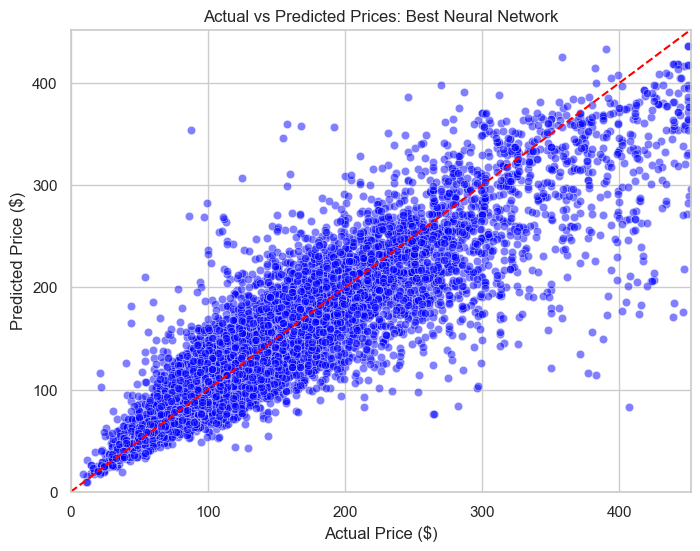

Learning and tuning the Neural Network completed.


In [849]:

Neural_Network_Model = 'Neural Network'

# Define the Neural Network Architecture
mlp_model = MLPRegressor(              
    solver='adam',                   
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

models[Neural_Network_Model] = {
    # max_iter=10000 ensures the algorithm has enough time to converge on a solution
    'model': mlp_model, 
    'best_tuned_pipeline': None,
    'param_grid': {
        'regressor__hidden_layer_sizes': [
            (128, 64, 32),       # The baseline architecture
            (128, 64),           # Shallower (less prone to overfitting)
            (256, 128, 64),       # Wider/Deeper (can capture more complex features)
            (256, 128, 128, 64, 32) 
        ],
        
        # 2. Activation Functions: How the neurons fire
        # ReLU is standard, but Tanh sometimes performs beautifully on scaled geographic data
        'regressor__activation': ['relu', 'tanh'],
        
        # 3. L2 Regularization (Alpha): The Overfitting Penalty
        # Because you have 90+ binary amenities, the network might overfit. 
        # Increasing alpha forces the network to keep its weights smaller and more generalized.
        'regressor__alpha': [0.0001, 0.001, 0.01],
        
        # 4. Learning Rate: How aggressively the optimizer adjusts weights
        # 0.001 is default. 0.01 is faster but might overshoot the optimal mathematical minimum.
        'regressor__learning_rate_init': [0.001, 0.01]
    }
}

tune_regressor(
    model_name=Neural_Network_Model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5
)

#### Training and Validation Time

In [850]:
results = get_model_training_validating_time(Neural_Network_Model)

Total time spent TRAINING (Fitting): 21343.49 seconds
Total time spent PREDICTING (Scoring): 69.86 seconds
Grand Total Algorithm Processing Time: 21413.35 seconds


#### Learning Curve
Here we are Plotting the error against the number of training samples


Calculating learning curve for Neural Network...


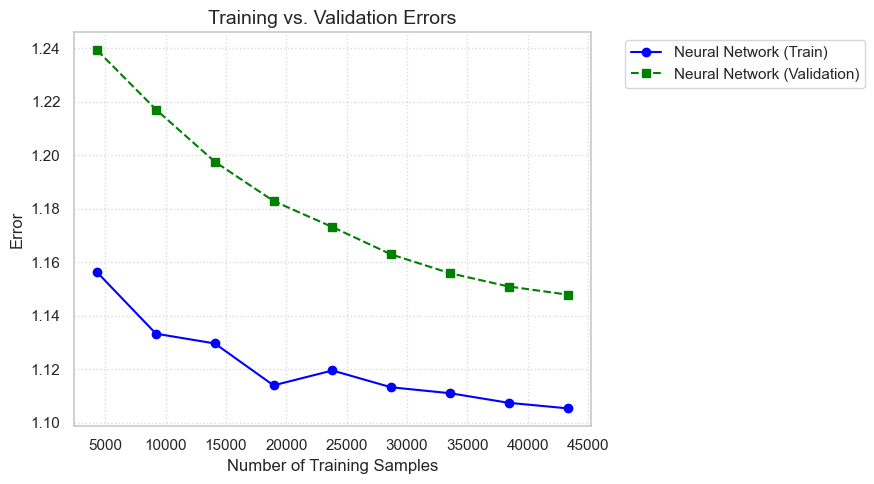

In [851]:
draw_training_vs_validation_error_curve(Neural_Network_Model)

#### Neural Network Results
Our Neural Network experiment yield good predictive power at a significant computational cost.

**Mean Absolute Error (MAE) ($19.72)**:
On average, the Neural Network's predicted nightly rate is off by under $20.

**Root Mean Squared Error (RMSE) ($32.58)**:
This model shaved over $5 off our RMSE compared to the baseline model. This indicates that Neural Network is good in making fewer "large magnitude" mistakes.

**R-squared (0.833)**: The model successfully explains over 83% of the variance in pricing.

**The Computational Cost**:<br>
- Training Time (~5.9 Hours): This is a primary drawback of this approach. The deep architecture required significant time to converge.
- Validation Time (~70 Seconds): While training was slow, the inference is nearly instantaneous.

**Hyperparameter Insights**:<br>
- The optimizer selected the tanh activation function over the standard relu. 
- The search selected our widest and deepest proposed architecture (256, 128, 64), which confirms that mapping interactions between dense geographic arrays and highly sparse categorical matrices requires substantial mathematical capacity.


## 4. Conclusion and Final Model Comparison


After systematically training, tuning, and evaluating five distinct machine learning algorithms, we can draw definitive conclusions about how different algorithms perform in short-term rental pricing prediction task.


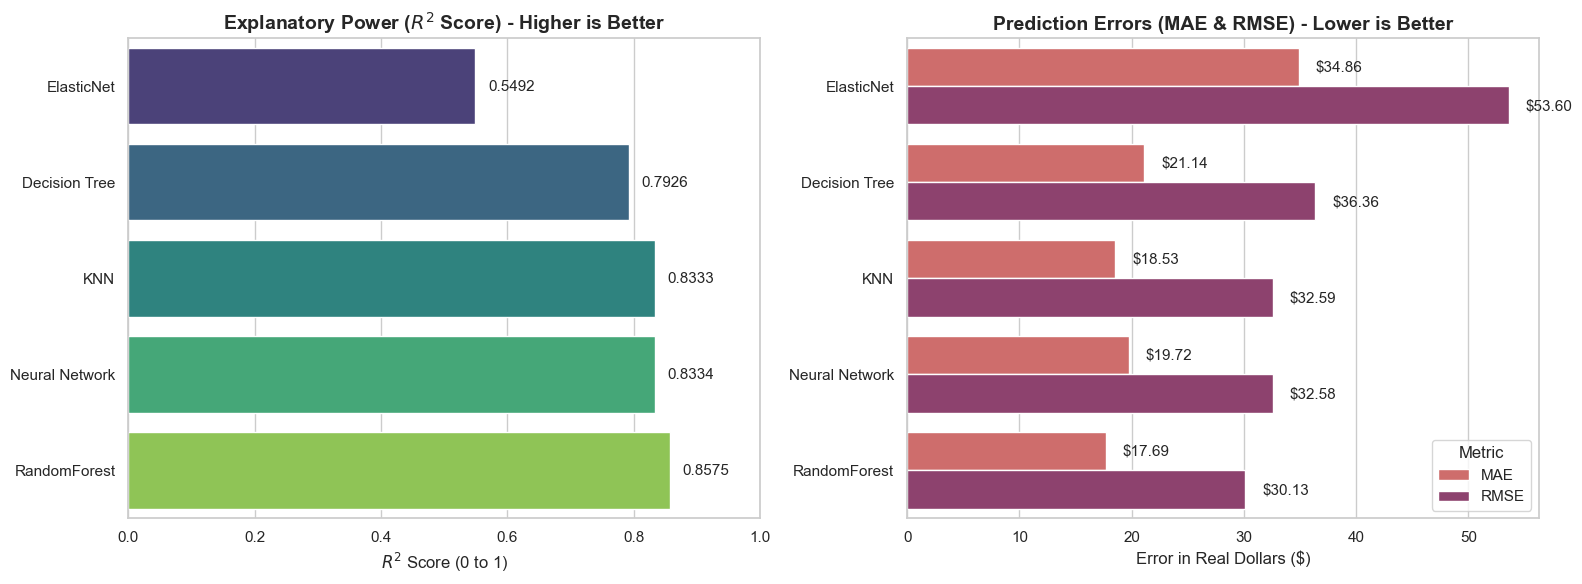

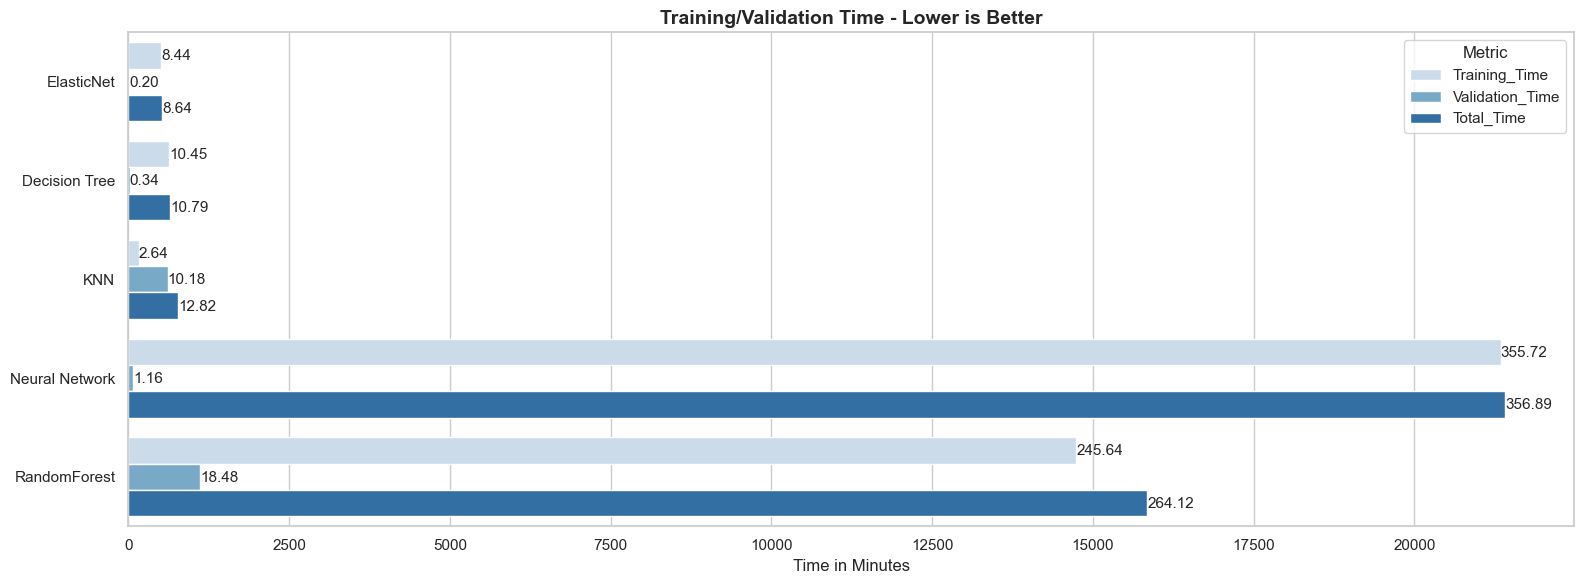

In [ ]:
results_data = {
    'Model': [],
    'R2': [],
    'MAE': [],
    'RMSE': [],
    'Training_Time': [],
    'Validation_Time': [],
    'Total_Time': [],
}

for model_name, metrics in models.items():
    results_data['Model'].append(model_name)
        
    results_data['R2'].append(metrics.get('r2', 0))
    results_data['MAE'].append(metrics.get('mae', 0))
    results_data['RMSE'].append(metrics.get('rmse', 0))

    total_fit_time_seconds, total_score_time_seconds, grand_total_seconds = get_model_training_validating_time(model_name, _print=False)

    results_data['Training_Time'].append(total_fit_time_seconds)
    results_data['Validation_Time'].append(total_score_time_seconds)
    results_data['Total_Time'].append(grand_total_seconds)


df_results = pd.DataFrame(results_data)

# Sort the models by R2 score so the charts flow logically from worst to best
df_results = df_results.sort_values(by='R2', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: R-squared (Explanatory Power) ---
sns.barplot(data=df_results, x='R2', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Explanatory Power ($R^2$ Score) - Higher is Better', fontsize=14, fontweight='bold')
axes[0].set_xlabel('$R^2$ Score (0 to 1)', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.0)

# Add exact data labels to the bars
for p in axes[0].patches:
    width = p.get_width()
    axes[0].text(width + 0.02, p.get_y() + p.get_height()/2. + 0.05,
            f'{width:.4f}', ha="left", fontsize=11)

# --- PLOT 2: MAE & RMSE (Prediction Errors) ---
df_errors = df_results.melt(id_vars='Model', value_vars=['MAE', 'RMSE'], var_name='Metric', value_name='Error ($)')

sns.barplot(data=df_errors, x='Error ($)', y='Model', hue='Metric', ax=axes[1], palette='flare')
axes[1].set_title('Prediction Errors (MAE & RMSE) - Lower is Better', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error in Real Dollars ($)', fontsize=12)
axes[1].set_ylabel('')

# Add exact data labels to the bars
for p in axes[1].patches:
    width = p.get_width()
    if width > 0: # Avoid errors on empty patches
        axes[1].text(width + 1.5, p.get_y() + p.get_height()/2. + 0.05,
                f'${width:.2f}', ha="left", fontsize=11)

plt.tight_layout()
plt.show()


fig = plt.subplots(1, 1, figsize=(16, 6), squeeze=True)
# --- PLOT 3: Timing (Computational Cost) ---
df_times = df_results.melt(id_vars='Model', value_vars=['Training_Time', 'Validation_Time', 'Total_Time'], var_name='Metric', value_name='Time (Seconds)')

chart = sns.barplot(data=df_times, x='Time (Seconds)', y='Model', hue='Metric', palette='Blues')
chart.set_title('Training/Validation Time - Lower is Better', fontsize=14, fontweight='bold')
chart.set_xlabel('Time in Minutes', fontsize=12)
chart.set_ylabel('')

# Add exact data labels to the bars
for p in chart.patches:
    width = p.get_width()
    if width > 0: # Avoid errors on empty patches
        chart.text(width + 1.5, p.get_y() + p.get_height()/2. + 0.05,
                f'{(width/60):.2f}', ha="left", fontsize=11)

plt.tight_layout()
plt.show()

By comparing our tuned models across Accuracy (MAE/RMSE/R²), and Computational Efficiency (Time) using the previous figures, a clear hierarchy emerges:

#### 1. The Baseline: ElasticNet
* **Performance:** R²: 0.549 | MAE: $34.86
* **Takeaway:** As expected, standard linear algorithms struggled heavily. The ElasticNet's low R² mathematically proves short-term rental market pricing is driven by highly complex, non-linear relationships (especially geographic boundaries) that cannot be mapped with straight lines.

#### 2. The Mid-Tier: Decision Tree
* **Performance:** R²: 0.793 | MAE: $21.14
* **Takeaway:** Moving to a tree-based architecture immediately jumped our accuracy by over 24%. It handled the non-linear geography well and was incredibly fast to train, but a single tree lacks the ability to perfectly capture the contributions of all sparse high-dimensional attributes.

#### 3. The Advanced Competitors: KNN & Neural Network
* **Performance:** Both achieved an R² of ~0.833 | MAE: (KNN: $18.23, Neural Network: $19.72). 
* **Takeaway:** Both models performed exceptionally well but presented distinct operational trade-offs. The Neural Network delivered a strong MAE ($19.72) but was the most computationally expensive model to train (nearly 6 hours). KNN delivered an even better MAE ($18.53) and trained quickly, but has a massive validation times compared to Neural Network due to the lazy-learning nature of distance calculations.

#### 4. The Champion: Random Forest
* **Performance:** R²: 0.858 | MAE: $17.69
* **Takeaway:** The Random Forest Ensemble is our definitive winner. By leveraging the use of multiple decision trees, it achieved the highest explanatory power (capturing nearly 86% of the variance in the price) and the lowest overall error. However, it was computationally heavy to train (~4.4 hours), and its inference time remains is the highest but it still reasonable when we want to predict a price of a few listings in a real-app.


### The Data Bottleneck
A critical finding from our learning curve diagnostics is that **all non-linear models (Decision Tree, KNN, Neural Network, and Random Forest) share the exact same learning behavior.** They all show a persistent variance gap (moderate overfitting) and a validation curve that is still sloping downwards at our maximum training sample size of 45,000 listings. 

This means our advanced models are **"data-hungry."** They have the capacity to learn more, but they are currently bottlenecked by the size of the dataset.


### Business Conclusion
The ultimate objective of this project was to engineer a data-driven pricing tool that empowers property owners to predict their optimal nightly rate using their specific physical characteristics, exact location, and offered amenities. Based on our comprehensive evaluation, we propose the tuned Random Forest as the definitive, actionable business solution. Furthermore, because our learning curve diagnostics revealed that this architecture is highly "data-hungry," our primary recommendation for future improvement is to collect a larger volume of listing data to fully maximize the model's predictive accuracy.